# Fractal layouts and generative L-systems

Phases 4–5 of `harmonic_geometry` expose deterministic fractal generators
that turn a chord into a self-similar layout: Stern-Brocot tree, continued
fractions, Farey sequences, iterated-function systems, L-systems, and
recursive polygons. Every generator returns a `GeometryData` that the
`plotting` submodule renders without further arguments.


In [1]:
import warnings
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt

from biotuner.harmonic_geometry import HarmonicInput, plotting

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110


In [2]:
from biotuner.harmonic_geometry import (
    HarmonicInput, plotting,
    stern_brocot_tree, continued_fraction_rectangles, farey_sequence_layout,
    subharmonic_tree, ifs_harmonic,
    lsystem_from_ratios, recursive_polygon, self_similar_tuning,
)

CHORDS = {
    "Major": HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(3, 2)]),
    "Sus4":  HarmonicInput(ratios=[Fraction(1), Fraction(4, 3), Fraction(3, 2)]),
    "Dom7":  HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(3, 2),
                                    Fraction(7, 4)]),
    "Dim7":  HarmonicInput(ratios=[Fraction(1), Fraction(6, 5),
                                    Fraction(7, 5), Fraction(12, 7)]),
}


## Stern-Brocot tree — chord-driven layouts

`stern_brocot_tree` builds the binary tree of mediants up to a given depth
and lays it out either as a regular dyadic tree (``layout="tree"``) or in
the Poincaré disk (``layout="hyperbolic"``).

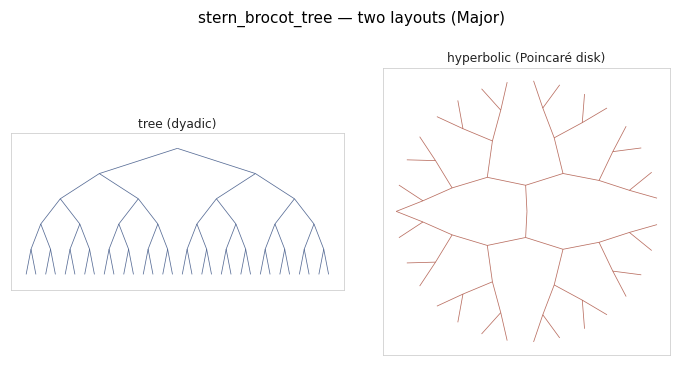

In [3]:
geoms  = [stern_brocot_tree(CHORDS["Major"], max_depth=6, layout=lay)
          for lay in ("tree", "hyperbolic")]
plotting.gallery(geoms, titles=["tree (dyadic)", "hyperbolic (Poincaré disk)"],
                 n_cols=2,
                 suptitle="stern_brocot_tree — two layouts (Major)");


## Continued-fraction rectangles

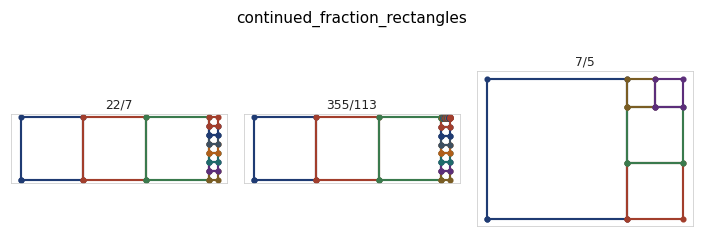

In [4]:
ratios = [Fraction(22, 7), Fraction(355, 113), Fraction(7, 5)]
geoms = [continued_fraction_rectangles(r) for r in ratios]
plotting.gallery(geoms, titles=[str(r) for r in ratios], n_cols=3,
                 suptitle="continued_fraction_rectangles");


## Farey sequence layouts

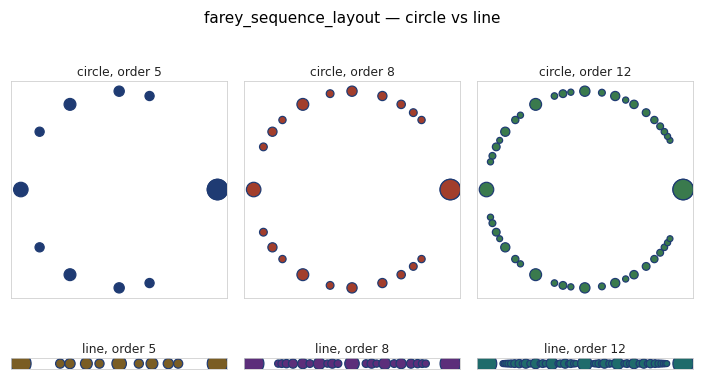

In [5]:
orders = [5, 8, 12]
geoms_circle = [farey_sequence_layout(o, layout="circle") for o in orders]
geoms_line   = [farey_sequence_layout(o, layout="line")   for o in orders]
plotting.gallery(geoms_circle + geoms_line,
                 titles=[f"circle, order {o}" for o in orders]
                       + [f"line, order {o}"   for o in orders],
                 n_cols=3,
                 suptitle="farey_sequence_layout — circle vs line");


## Subharmonic tree — chord-driven polar layout

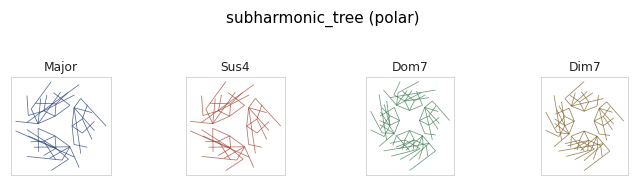

In [6]:
geoms  = [subharmonic_tree(CHORDS[n], depth=4, n_harmonics=4, layout="polar")
          for n in ("Major", "Sus4", "Dom7", "Dim7")]
plotting.gallery(geoms, titles=list(CHORDS.keys()), n_cols=4,
                 suptitle="subharmonic_tree (polar)");


## Iterated-function system from a chord

Each ratio defines a contractive affine map; their non-empty intersection
is the IFS attractor. Sampled via the chaos game.

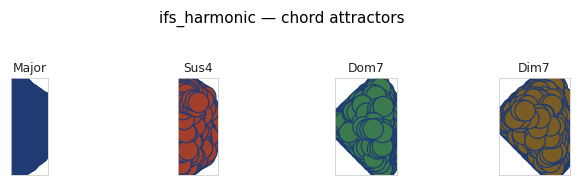

In [7]:
rng = np.random.default_rng(0)
geoms = [ifs_harmonic(CHORDS[n], n_points=30_000,
                       contraction="ratio_inverse", rng=rng)
         for n in ("Major", "Sus4", "Dom7", "Dim7")]
plotting.gallery(geoms, titles=list(CHORDS.keys()), n_cols=4,
                 suptitle="ifs_harmonic — chord attractors");


## L-system curves and recursive polygons

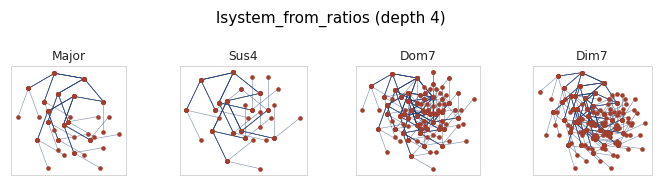

In [8]:
geoms = [lsystem_from_ratios(CHORDS[n], depth=4) for n in CHORDS]
plotting.gallery(geoms, titles=list(CHORDS.keys()), n_cols=4,
                 suptitle="lsystem_from_ratios (depth 4)");


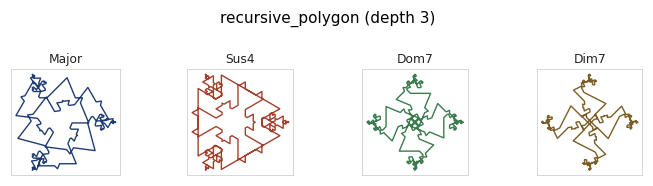

In [9]:
geoms = [recursive_polygon(CHORDS[n], depth=3) for n in CHORDS]
plotting.gallery(geoms, titles=list(CHORDS.keys()), n_cols=4,
                 suptitle="recursive_polygon (depth 3)");


## Self-similar tuning (nested ratio scaffolds)

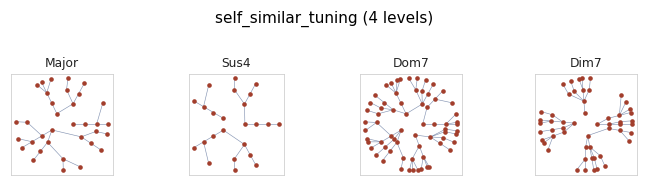

In [10]:
geoms = [self_similar_tuning(CHORDS[n], n_levels=4) for n in CHORDS]
plotting.gallery(geoms, titles=list(CHORDS.keys()), n_cols=4,
                 suptitle="self_similar_tuning (4 levels)");
